# 00 — Initial Data Cleaning and Exploratory Analysis

This notebook performs the first pass of data cleaning and exploratory analysis for the Job Intelligence Engine. Its purpose is to transform the raw job postings dataset into a cleaner, more interpretable interim dataset that will be used as the starting point for Chapter 0 (Job Title Normalization and Skill Extraction).

### **Goals of this notebook**
- Inspect raw columns and understand data quality.
- Handle missing values encoded as `-1`.
- Extract state information from `Location` and `Headquarters`.
- Parse and standardize salary ranges, including conversion of hourly pay to annual estimates.
- Clean and simplify categorical variables (e.g., ownership).
- Standardize `Founded`, `Rating`, and related features.
- Remove redundant columns (e.g., `Unnamed: 0`, duplicated indices).
- Produce visual summaries (distributions, counts, missingness).
- Save a clean, intermediate dataset to `data/interim/`.

### **Output**
- `data/interim/cleaned_jobs_interim.csv`  
A checkpoint dataset that captures all basic structural cleaning and prepares the project for Chapter 0.

---

This notebook is intentionally exploratory.  
It defines the *rules* that will eventually be formalized in the project pipeline once all chapters are complete.


## Set-Up

Check the system environment, we should be working on something like `/.venv/bin/python`

In [1]:
import sys
print(sys.executable)

/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/.venv/bin/python


Check the path to the project root. This is needed to load files from within the project.

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

Retrieve the file path from the data folder.

In [3]:
from src.job_intel.config import RAW_JOBS_FILE
print(RAW_JOBS_FILE)

/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/data/raw/DataScientist.csv


## Import libraries and data

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv(RAW_JOBS_FILE)
df.head(10)

,Unnamed: 0,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,0,Senior Data Scientist,$111K-$181K (Glassdoor est.),"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,Hopper\n3.5,"New York, NY","Montreal, Canada",501 to 1000 employees,2007,Company - Private,Travel Agencies,Travel & Tourism,Unknown / Non-Applicable,-1,-1
1,1,1,"Data Scientist, Product Analytics",$111K-$181K (Glassdoor est.),"At Noom, we use scientifically proven methods ...",4.5,Noom US\n4.5,"New York, NY","New York, NY",1001 to 5000 employees,2008,Company - Private,"Health, Beauty, & Fitness",Consumer Services,Unknown / Non-Applicable,-1,-1
2,2,2,Data Science Manager,$111K-$181K (Glassdoor est.),Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,-1.0,Decode_M,"New York, NY","New York, NY",1 to 50 employees,-1,Unknown,-1,-1,Unknown / Non-Applicable,-1,True
3,3,3,Data Analyst,$111K-$181K (Glassdoor est.),Sapphire Digital seeks a dynamic and driven mi...,3.4,Sapphire Digital\n3.4,"Lyndhurst, NJ","Lyndhurst, NJ",201 to 500 employees,2019,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,"Zocdoc, Healthgrades",-1
4,4,4,"Director, Data Science",$111K-$181K (Glassdoor est.),"Director, Data Science - (200537)\nDescription...",3.4,United Entertainment Group\n3.4,"New York, NY","New York, NY",51 to 200 employees,2007,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"BBDO, Grey Group, Droga5",-1
5,5,5,Data Scientist,$111K-$181K (Glassdoor est.),Job Brief\n\nThe ideal candidate will have pre...,2.9,IFG Companies\n2.9,"New York, NY","Hartford, CT",201 to 500 employees,1985,Company - Private,Insurance Carriers,Insurance,Unknown / Non-Applicable,"Colony Specialty, Markel, RLI",-1
6,6,6,Quantitative Researcher,$111K-$181K (Glassdoor est.),Experience: Entry-level (PhD Program) or Exper...,4.4,PDT Partners\n4.4,"New York, NY","New York, NY",51 to 200 employees,1993,Company - Private,Investment Banking & Asset Management,Finance,Unknown / Non-Applicable,-1,-1
7,7,7,Quantitative Research Associate,$111K-$181K (Glassdoor est.),Seeking a quant to work with senior researcher...,-1.0,Enlightenment Research,"New York, NY","New York, NY",1 to 50 employees,-1,Unknown,-1,-1,Unknown / Non-Applicable,-1,True
8,8,8,AI Scientist,$111K-$181K (Glassdoor est.),Paige is a software company helping pathologis...,5.0,Paige\n5.0,"New York, NY","New York, NY",1 to 50 employees,2018,Company - Private,Enterprise Software & Network Solutions,Information Technology,Unknown / Non-Applicable,-1,True
9,9,9,Quantitative Researcher,$111K-$181K (Glassdoor est.),"About the Position\n\n\nAt Jane Street, we con...",4.8,Jane Street\n4.8,"New York, NY","New York, NY",501 to 1000 employees,2000,Company - Private,Investment Banking & Asset Management,Finance,Unknown / Non-Applicable,-1,-1


## Data exploration and feature engineering

### Exploring missing data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3909 entries, 0 to 3908
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3909 non-null   int64  
 1   index              3909 non-null   int64  
 2   Job Title          3909 non-null   object 
 3   Salary Estimate    3909 non-null   object 
 4   Job Description    3909 non-null   object 
 5   Rating             3909 non-null   float64
 6   Company Name       3909 non-null   object 
 7   Location           3909 non-null   object 
 8   Headquarters       3909 non-null   object 
 9   Size               3909 non-null   object 
 10  Founded            3909 non-null   int64  
 11  Type of ownership  3909 non-null   object 
 12  Industry           3909 non-null   object 
 13  Sector             3909 non-null   object 
 14  Revenue            3909 non-null   object 
 15  Competitors        3909 non-null   object 
 16  Easy Apply         3909 

It seems that we do not have Null cells per se. Maybe Nulls are encoded differently. From the first few columns above I can see that some Nulls are filled with '-1'. So, perhas one of the first thing I will do is to change those -1 to NUll values.

In [7]:
# Replacing `-1` with `NaN`

df = df.replace(-1, np.nan)
df = df.replace('-1', np.nan)

Easy Apply           95.804554
Competitors          70.606293
Founded              24.993605
Sector               13.967767
Industry             13.967767
Rating               10.463034
Headquarters          6.139678
Size                  5.858276
Type of ownership     5.858276
Revenue               5.858276
Location              0.000000
index                 0.000000
Company Name          0.000000
Job Description       0.000000
Salary Estimate       0.000000
Job Title             0.000000
Unnamed: 0            0.000000
dtype: float64

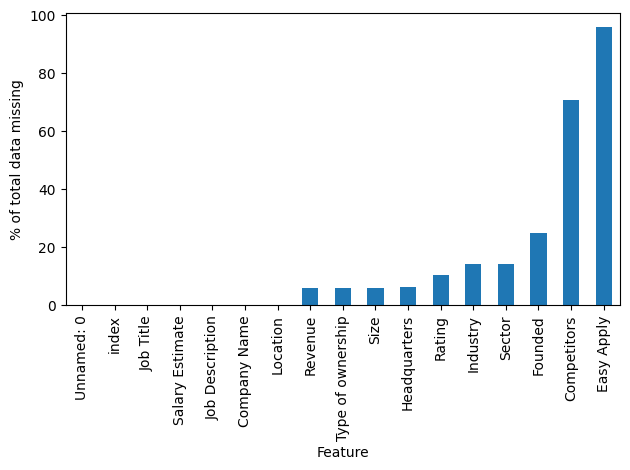

In [8]:
df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values().plot(kind = 'bar')
plt.ylabel('% of total data missing')
plt.xlabel('Feature')
plt.tight_layout()

df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values(ascending=False)

Easy apply is missing nearly 96% of the data. Competitors is missing around 71% of the data. These two features are definetely unimportant for the project and given the percentage of missing values it should be safe to just ignore these two variables in the future

In [9]:
df = df.drop(['Easy Apply', 'Competitors'], axis = 1)

We can also drop the indices `Unnamed: 0` and `index`

In [10]:
df = df.drop(['Unnamed: 0', 'index'], axis = 1)

### Exploring value range in remaining variables

In [11]:
df['Revenue'].value_counts()

Revenue
Unknown / Non-Applicable            1163
$10+ billion (USD)                   599
$100 to $500 million (USD)           338
$50 to $100 million (USD)            214
$2 to $5 billion (USD)               211
$10 to $25 million (USD)             191
$1 to $2 billion (USD)               180
$1 to $5 million (USD)               170
$25 to $50 million (USD)             143
$5 to $10 billion (USD)              133
Less than $1 million (USD)           124
$500 million to $1 billion (USD)     114
$5 to $10 million (USD)              100
Name: count, dtype: int64

In [12]:
df['Company Name'].value_counts()

Company Name
Apple\n4.1                               60
IBM\n3.7                                 57
Amazon\n3.9                              47
Staffigo Technical Services, LLC\n5.0    28
Facebook\n4.5                            25
                                         ..
Crawford Thomas Recruiting\n5.0           1
Corporate\n2.0                            1
Infogium Technologies, LLC\n5.0           1
Microtek Digital LLC                      1
Data Resource Technologies\n4.0           1
Name: count, Length: 2075, dtype: int64

Company Name will be excluded due to extremely high cardinality (>2,000 unique values), making it unsuitable for generalizable modelling. Revenue will also be removed, given that ~30% of its values are unknown and it is not essential for the downstream tasks of salary prediction, skill inference, or job similarity. In contrast, higher-level company attributes like Sector (21 categories) will be retained because they offer interpretable, generalizable information that supports the project’s core modelling goals.

In [13]:
df = df.drop(['Company Name', 'Revenue'], axis = 1)

### Simplify location and headquarters to state level variable

In [14]:
df['Location'].value_counts()

Location
Austin, TX                  345
Chicago, IL                 330
San Diego, CA               304
New York, NY                303
Houston, TX                 219
                           ... 
Brea, CA                      1
Feasterville Trevose, PA      1
West Conshohocken, PA         1
Bensalem, PA                  1
Hilliard, OH                  1
Name: count, Length: 191, dtype: int64

In [15]:
df['state'] = df['Location'].str.extract(r'(?<=,\s)([^,]+)$')
df['state'].value_counts()

state
TX                1253
CA                1069
IL                 363
PA                 324
NY                 313
AZ                 295
OH                 177
FL                  69
NJ                  32
DE                  10
United Kingdom       4
Name: count, dtype: int64

In [16]:
df['state_hq'] = df['Headquarters'].str.extract(r'(?<=,\s)([^,]+)$')
df['state_hq'] = df['state_hq'].str.replace('061', 'NY')
df['state_hq'].value_counts()

state_hq
CA         916
TX         458
NY         393
IL         251
NJ         188
          ... 
Denmark      1
AR           1
Cyprus       1
Mexico       1
WV           1
Name: count, Length: 76, dtype: int64

In [17]:
df = df.drop(['Location', 'Headquarters'], axis = 1)

The Location and Headquarters columns contained highly granular city-level information (191 and 542 unique values, respectively), which is too detailed for robust modelling and creates unnecessary sparsity. To retain meaningful geographic structure while reducing noise, both variables were simplified to state-level categories. State captures the salary and job-market patterns relevant for downstream modelling without introducing excessive cardinality. After extracting the state codes, the original Location and Headquarters columns were dropped, as they no longer added useful information.

### Salary range

Now let's move on the range variables. I need to clean the text and extract the min and max from the range.

In [18]:
df['Salary Estimate'].value_counts()

Salary Estimate
$93K-$151K (Glassdoor est.)         62
$113K-$180K (Glassdoor est.)        61
$71K-$122K (Glassdoor est.)         60
$111K-$175K (Glassdoor est.)        60
$119K-$147K (Glassdoor est.)        44
                                    ..
$34-$53 Per Hour(Glassdoor est.)     7
$99K-$173K (Glassdoor est.)          6
$10-$26 Per Hour(Glassdoor est.)     3
$146K-$175K (Glassdoor est.)         3
$41K-$74K (Glassdoor est.)           1
Name: count, Length: 148, dtype: int64

In [19]:
df['sal_clean'] = df['Salary Estimate'].str.replace(' (Glassdoor est.)', '').str.replace('(Glassdoor est.)', '').str.replace('(Employer est.)', '').str.replace('$', '').str.replace('K', '').str.replace(' ', '') 
df['sal_clean'].value_counts()

sal_clean
93-151          62
113-180         61
71-122          60
111-175         60
119-147         44
                ..
34-53PerHour     7
99-173           6
10-26PerHour     3
146-175          3
41-74            1
Name: count, Length: 148, dtype: int64

In [20]:
df['is_hourly'] = df['sal_clean'].str.contains('PerHour', case=False)

In [21]:
df['sal_clean'] = df['sal_clean'].str.replace('PerHour', '')
df['sal_clean'].value_counts()

sal_clean
93-151     62
113-180    61
71-122     60
111-175    60
119-147    44
           ..
34-53       7
99-173      6
10-26       3
146-175     3
41-74       1
Name: count, Length: 148, dtype: int64

In [22]:
df[['sal_min_raw', 'sal_max_raw']] = df['sal_clean'].str.split('-', expand=True)
df['sal_min_raw'] = pd.to_numeric(df['sal_min_raw'], errors='coerce')
df['sal_max_raw'] = pd.to_numeric(df['sal_max_raw'], errors='coerce')

In [23]:
df['sal_min'] = np.where(df['is_hourly'],
                         df['sal_min_raw'] * 2080,
                         df['sal_min_raw'] * 1000)

df['sal_max'] = np.where(df['is_hourly'],
                         df['sal_max_raw'] * 2080,
                         df['sal_max_raw'] * 1000)

df['sal_mean'] = (df['sal_min'] + df['sal_max'])/2

In [24]:
df = df.drop(['Salary Estimate', 'sal_clean', 'is_hourly', 'sal_min_raw', 'sal_max_raw'], axis = 1)

### Size

In [25]:
df['Size'].value_counts()

Size
10000+ employees           993
51 to 200 employees        563
1001 to 5000 employees     553
1 to 50 employees          550
201 to 500 employees       418
501 to 1000 employees      307
5001 to 10000 employees    219
Unknown                     77
Name: count, dtype: int64

Since there are only 8 categories, we will keep size as it is for now

### Ownership

In [26]:
df['Type of ownership'].value_counts()

Type of ownership
Company - Private                 1933
Company - Public                  1114
Nonprofit Organization             207
Subsidiary or Business Segment     160
Government                          91
College / University                77
Unknown                             38
Contract                            17
Hospital                            16
Private Practice / Firm             12
School / School District             5
Other Organization                   5
Self-employed                        4
Franchise                            1
Name: count, dtype: int64

In [27]:
# start by standardising to lowercase for easier matching
df['ownership_clean'] = df['Type of ownership'].str.lower()

df['ownership_clean'] = (
    df['ownership_clean']
    .str.replace('company - private', 'private')
    .str.replace('private practice / firm', 'private')
    .str.replace('self-employed', 'private')

    .str.replace('company - public', 'public')
    .str.replace('subsidiary or business segment', 'public')
    .str.replace('franchise', 'public')

    .str.replace('nonprofit organization', 'nonprofit')
    .str.replace('college / university', 'nonprofit')
    .str.replace('school / school district', 'nonprofit')
    .str.replace('hospital', 'nonprofit')

    .str.replace('government', 'government')

    # everything else becomes unknown
    .apply(lambda x: x if x in ['private','public','nonprofit','government','unknown'] 
                    else 'unknown')
)
df = df.drop('Type of ownership', axis = 1)

Type of ownership contains many small or ambiguous categories (e.g., “Subsidiary”, “Hospital”, “Private Practice”, “Other Organization”).
These categories add noise, have low counts, and do not provide meaningful distinctions for modelling.

To simplify the feature and improve interpretability, we collapsed all entries into four main groups:

* Private
* Public
* Nonprofit
* Government
* Any rare or unclear labels were mapped to “Unknown”.

This reduces sparsity, prevents overfitting, and keeps only the ownership structure that could realistically influence salary or company behaviour.

### Year

In [28]:
df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce').astype('Int64')

## EDA

Founded            24.993605
Industry           13.967767
Sector             13.967767
Rating             10.463034
state_hq            6.139678
Size                5.858276
Job Title           0.000000
Job Description     0.000000
state               0.000000
sal_min             0.000000
sal_max             0.000000
sal_mean            0.000000
ownership_clean     0.000000
dtype: float64

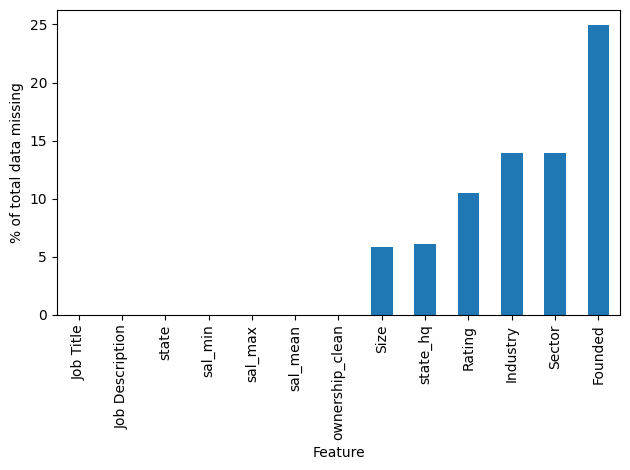

In [29]:
df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values().plot(kind = 'bar')
plt.ylabel('% of total data missing')
plt.xlabel('Feature')
plt.tight_layout()

df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values(ascending=False)

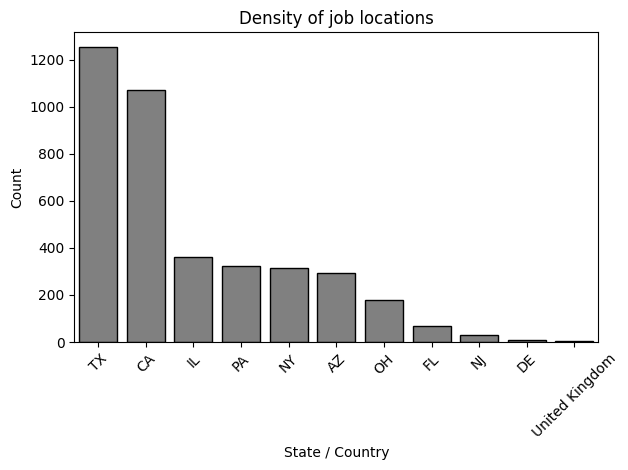

In [30]:
sns.countplot(
    data = df,
    x = 'state',
    color='grey',
    edgecolor = 'black',
    order=df['state'].value_counts().index
)
plt.xticks(rotation = 45)
plt.xlabel('State / Country')
plt.ylabel('Count')
plt.title('Density of job locations')
plt.tight_layout()

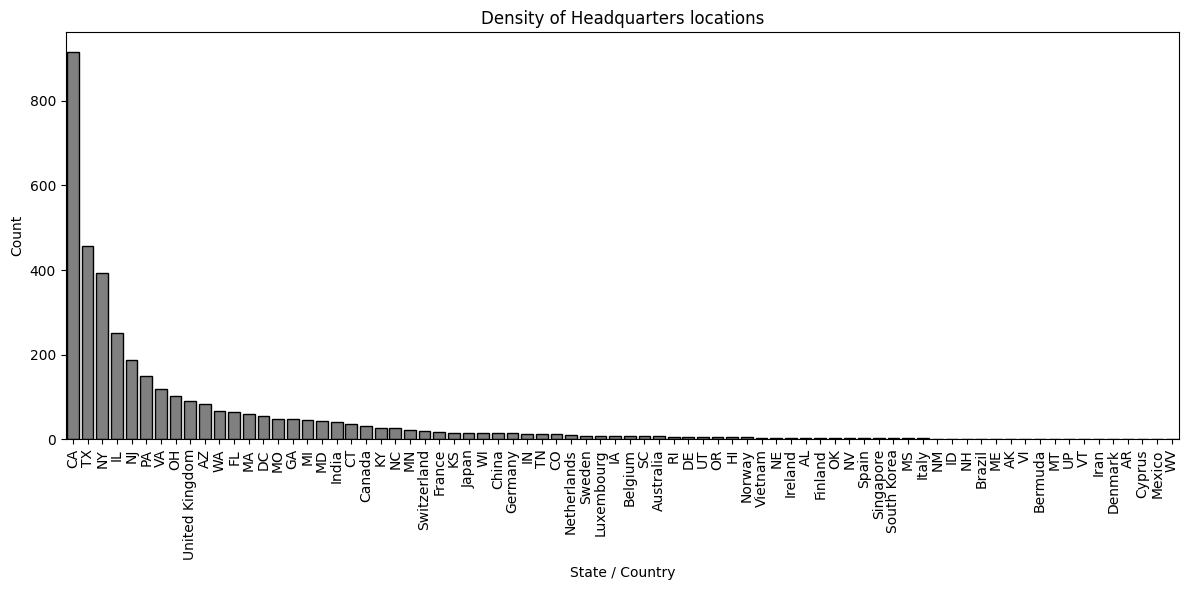

In [31]:
plt.figure(figsize=(12,6))
sns.countplot(
    data = df,
    x = 'state_hq',
    color='grey',
    edgecolor = 'black',
    order=df['state_hq'].value_counts().index
)
plt.xticks(rotation = 90)
plt.xlabel('State / Country')
plt.ylabel('Count')
plt.title('Density of Headquarters locations')
plt.tight_layout()

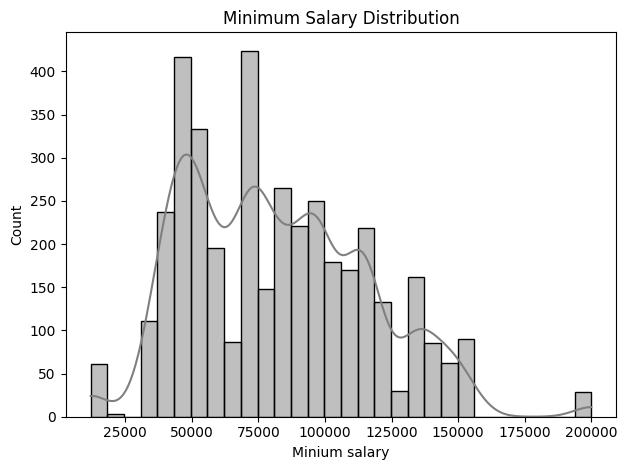

In [32]:
sns.histplot(
    data = df,
    x = 'sal_min',
    color='grey',
    edgecolor = 'black',
    bins=30,
    kde=True
)

plt.xlabel('Minium salary')
plt.ylabel('Count')
plt.title('Minimum Salary Distribution')
plt.tight_layout()

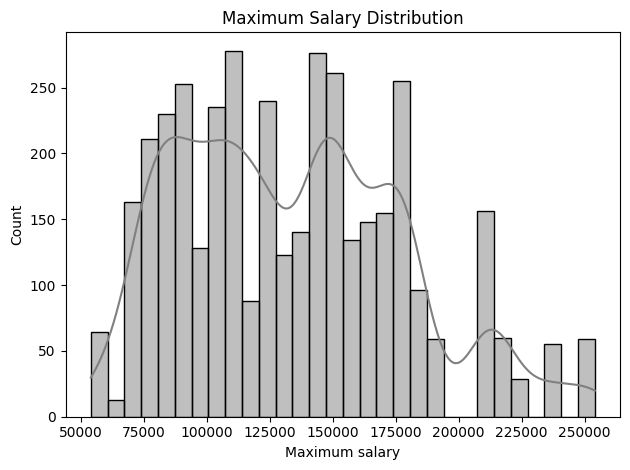

In [33]:
sns.histplot(
    data = df,
    x = 'sal_max',
    color='grey',
    edgecolor = 'black',
    bins=30,
    kde=True,
)

plt.xlabel('Maximum salary')
plt.ylabel('Count')
plt.title('Maximum Salary Distribution')
plt.tight_layout()

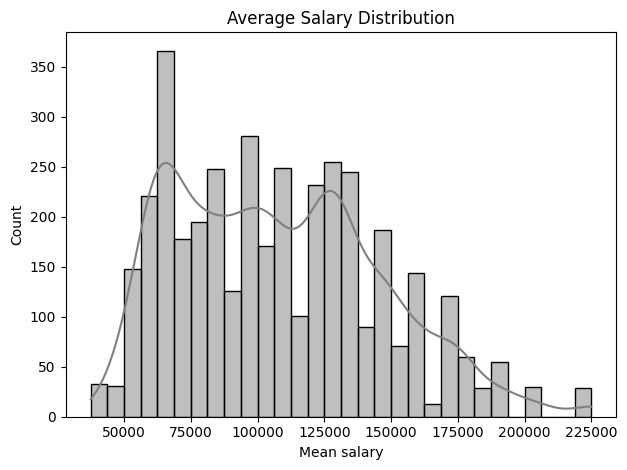

In [34]:
sns.histplot(
    data = df,
    x = 'sal_mean',
    color='grey',
    edgecolor = 'black',
    bins=30,
    kde=True,
)

plt.xlabel('Mean salary')
plt.ylabel('Count')
plt.title('Average Salary Distribution')
plt.tight_layout()

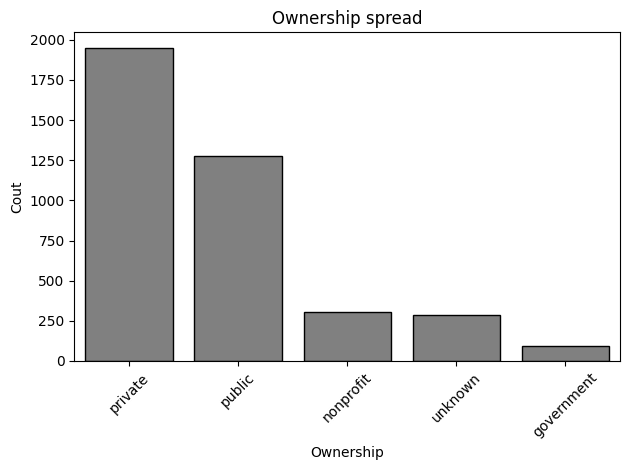

In [35]:
sns.countplot(
    data = df,
    x = 'ownership_clean',
    color='grey',
    edgecolor = 'black',
    order=df['ownership_clean'].value_counts().index
)
plt.xticks(rotation = 45)
plt.xlabel('Ownership')
plt.ylabel('Cout')
plt.title('Ownership spread')
plt.tight_layout()

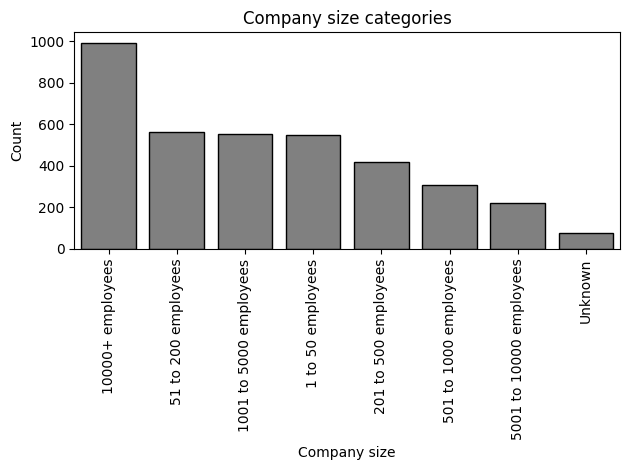

In [36]:
sns.countplot(
    data = df,
    x = 'Size',
    color='grey',
    edgecolor = 'black',
    order=df['Size'].value_counts().index
)
plt.xticks(rotation = 90)
plt.xlabel('Company size')
plt.ylabel('Count')
plt.title('Company size categories')
plt.tight_layout()

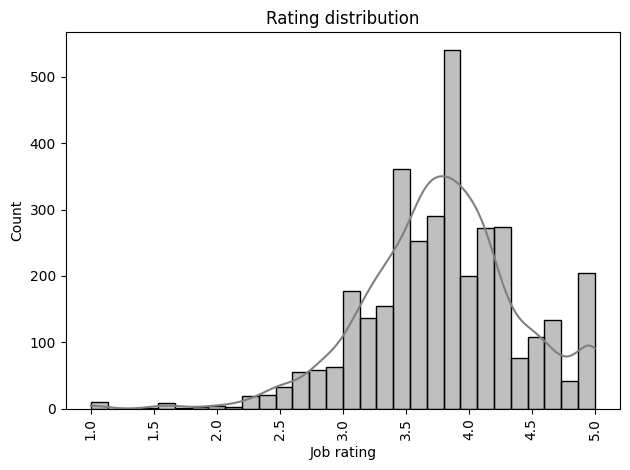

In [37]:
sns.histplot(
    data = df,
    x = 'Rating',
    color='grey',
    edgecolor = 'black',
    bins = 30,
    kde = True
)
plt.xticks(rotation = 90)
plt.xlabel('Job rating')
plt.ylabel('Count')
plt.title('Rating distribution')
plt.tight_layout()

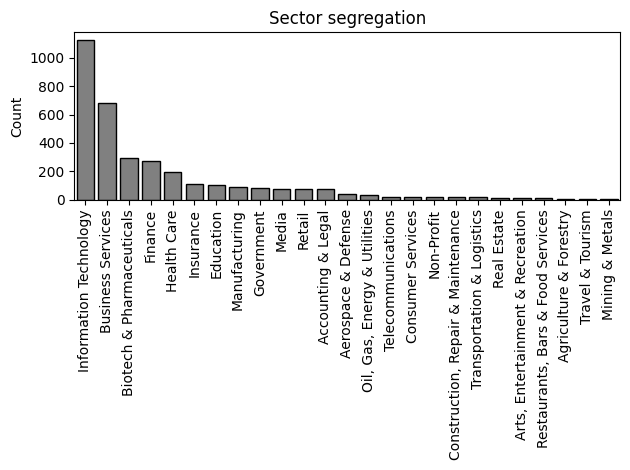

In [38]:
sns.countplot(
    data = df,
    x = 'Sector',
    color='grey',
    edgecolor = 'black',
    order=df['Sector'].value_counts().index
)
plt.xticks(rotation = 90)
plt.xlabel('')
plt.ylabel('Count')
plt.title('Sector segregation')
plt.tight_layout()

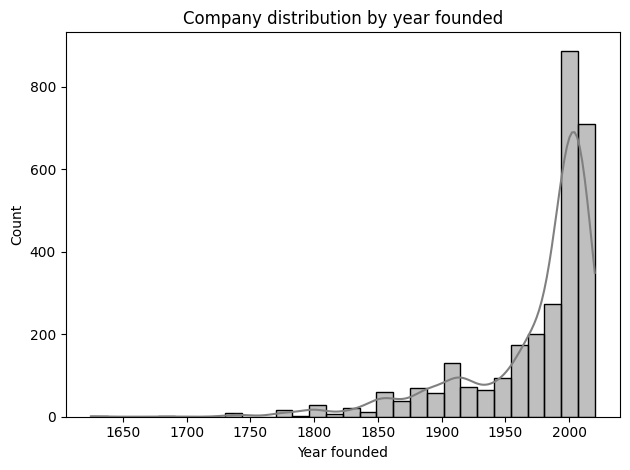

In [39]:
sns.histplot(
    data = df,
    x = 'Founded',
    color='grey',
    edgecolor = 'black',
    bins = 30,
    kde = True
)
plt.xlabel('Year founded')
plt.ylabel('Count')
plt.title('Company distribution by year founded')
plt.tight_layout()

In [40]:
from src.job_intel.config import INTERIM_DATA_DIR

INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [45]:
df.head(20)

,Job Title,Job Description,Rating,Size,Founded,Industry,Sector,state,state_hq,sal_min,sal_max,sal_mean,ownership_clean
0,Senior Data Scientist,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007,Travel Agencies,Travel & Tourism,NY,Canada,111000,181000,146000.0,private
1,"Data Scientist, Product Analytics","At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008,"Health, Beauty, & Fitness",Consumer Services,NY,NY,111000,181000,146000.0,private
2,Data Science Manager,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,<NA>,NaN,NaN,NY,NY,111000,181000,146000.0,unknown
3,Data Analyst,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019,Internet,Information Technology,NJ,NJ,111000,181000,146000.0,private
4,"Director, Data Science","Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007,Advertising & Marketing,Business Services,NY,NY,111000,181000,146000.0,private
5,Data Scientist,Job Brief\n\nThe ideal candidate will have pre...,2.9,201 to 500 employees,1985,Insurance Carriers,Insurance,NY,CT,111000,181000,146000.0,private
6,Quantitative Researcher,Experience: Entry-level (PhD Program) or Exper...,4.4,51 to 200 employees,1993,Investment Banking & Asset Management,Finance,NY,NY,111000,181000,146000.0,private
7,Quantitative Research Associate,Seeking a quant to work with senior researcher...,NaN,1 to 50 employees,<NA>,NaN,NaN,NY,NY,111000,181000,146000.0,unknown
8,AI Scientist,Paige is a software company helping pathologis...,5.0,1 to 50 employees,2018,Enterprise Software & Network Solutions,Information Technology,NY,NY,111000,181000,146000.0,private
9,Quantitative Researcher,"About the Position\n\n\nAt Jane Street, we con...",4.8,501 to 1000 employees,2000,Investment Banking & Asset Management,Finance,NY,NY,111000,181000,146000.0,private


In [44]:
df.isna().mean().sort_values().tail(8)

sal_mean           0.000000
ownership_clean    0.000000
Size               0.058583
state_hq           0.061397
Rating             0.104630
Industry           0.139678
Sector             0.139678
Founded            0.249936
dtype: float64

In [ ]:
df.info()
df.to_csv(INTERIM_DATA_DIR / "cleaned_jobs_interim.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3909 entries, 0 to 3908
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Job Title        3909 non-null   object 
 1   Job Description  3909 non-null   object 
 2   Rating           3500 non-null   float64
 3   Size             3680 non-null   object 
 4   Founded          2932 non-null   Int64  
 5   Industry         3363 non-null   object 
 6   Sector           3363 non-null   object 
 7   state            3909 non-null   object 
 8   state_hq         3669 non-null   object 
 9   sal_min          3909 non-null   int64  
 10  sal_max          3909 non-null   int64  
 11  sal_mean         3909 non-null   float64
 12  ownership_clean  3909 non-null   object 
dtypes: Int64(1), float64(2), int64(2), object(8)
memory usage: 401.0+ KB


## Summary of Data Cleaning Decisions

This notebook performs the initial cleaning and structuring of the raw Glassdoor job dataset. The following transformations were applied:

### 1. Missing values
- “-1” and “'-1'” were converted to `NaN`.
- Columns with extreme missingness and low modelling value were removed:
  - **Easy Apply** (~96% missing)
  - **Competitors** (~71% missing)

### 2. High-cardinality or low-utility columns
- **Company Name** (>2,000 unique values) removed to avoid sparse encoding.
- **Revenue** removed due to ~30% unknown values and limited modelling relevance.

### 3. Location and Headquarters simplification
- Extracted **state** codes from `Location` and `Headquarters` via regex.
- Corrected “061” → “NY”.
- Dropped original granular columns (`Location`, `Headquarters`).

### 4. Salary standardisation
- Cleaned salary strings (removed `$`, `K`, “est.” text, spaces).
- Identified hourly salaries (`is_hourly` flag).
- Removed “PerHour” before parsing.
- Split ranges into `sal_min_raw` and `sal_max_raw`.
- Converted text to numeric with `errors='coerce'`.
- Converted hourly wages to annual using `* 2080`.
- Converted K-ranges to full numbers using `* 1000`.
- Created final salary features:
  - `sal_min`, `sal_max`, `sal_mean`
- Dropped intermediate helper columns.

### 5. Size
- Kept as-is (only 8 categories).

### 6. Type of ownership
- Normalised cases and collapsed into four interpretable categories:
  - **private**, **public**, **nonprofit**, **government**
  - All others → “unknown”.
- Dropped the original column.

### 7. Founded year
- Converted to integer using:
  - `pd.to_numeric(..., errors='coerce').astype('Int64')`
  - Preserves missing values.

### 8. Output
- Final cleaned dataset saved to:
  `data/interim/cleaned_jobs_interim.csv`


# --- End of Notebook ---